EDA And Feature Engineering Of Google Play Store Dataset
Problem statement. Today, 1.85 million different apps are available for users to download. Android users have even more from which to choose, with 2.56 million available through the Google Play Store. These apps have come to play a huge role in the way we live our lives today. Our Objective is to find the Most Popular Category, find the App with largest number of installs , the App with largest size etc.
Data Collection.
The data consists of 20 column and 10841 rows.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df.head()

df.shape

df.info()

# summary of the  dataset 
df.describe() # so only rating column is numeric here


# handling missing values
df.isnull().sum()

# Observation : Dataset has missing values in Rating, Type,Current Ver and Android Ver



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [6]:
# Data cleaning 

# checking evry column and handling it 

df.head(2)

# making copy of the original data
df_copy=df.copy()
df_copy['Reviews'].unique()

df_copy['Reviews'].str.isnumeric().sum()
# one vlaue is not numeric

df_copy[~df_copy['Reviews'].str.isnumeric()]

# now dropping that one record
df_copy=df_copy.drop(df_copy.index[10472])

# now we can covert this review data type to int as we have dropped that 3.0M value of the review colum
## Convert Review Datatype to int
df_copy['Reviews']=df_copy['Reviews'].astype(int)

# checking for the size as it is numeric but data type is object becuase of M,K
# so coverting the data into k units 19m to 19000 and 9k will be 9 
# 19000k=19M
df_copy['Size'].unique()
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].str.replace('k','')
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)

df_copy['Size']=df_copy['Size'].astype(float)


df_copy['Size'].isnull().sum()
df_copy['Size']



KeyError: 'Reviews'

In [ ]:
df.head()

df_copy['Installs'].unique()
df_copy['Installs']=df_copy['Installs'].str.replace('+','')
df_copy['Installs']=df_copy['Installs'].str.replace(',','')

df_copy['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [ ]:
df_copy['Price'].unique()
df_copy['Price']=df_copy['Price'].str.replace('$','')

df_copy['Price'].unique()

df_copy['Installs']=df_copy['Installs'].astype('int')
df_copy['Price']=df_copy['Price'].astype('float')



In [ ]:
df_copy.head(2)
df_copy.info()

df_copy['Type'].unique()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


array(['Free', 'Paid', nan], dtype=object)

In [ ]:
## Handlling Last update feature
df_copy['Last Updated'].unique()

df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'])
df_copy['Day']=df_copy['Last Updated'].dt.day
df_copy['Month']=df_copy['Last Updated'].dt.month
df_copy['Year']=df_copy['Last Updated'].dt.year
df_copy.info()
df_copy.head(2)

# always try to save data after cleaning
# df_copy.to_csv('dataanalyst/google_playstore_cleaned.csv')thisis fopr if you e=want top save in another folder 

df_copy.to_csv('google_playstore_cleaned.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

Performing EDA after cleaning gthe data 

In [ ]:
# Business Objective
# To analysis which Apps are used by users based on Category,Genere,installation,size,type etc that help to Developer for their wright dimension.


# Solution of Business Objective#
# As per the above analysis FAMILY category has very much scope because it has all age group people. second category is GAME that has also scope.

# Eventhough apps from the categories like FAMILY, SOCIAL, COMMUNICATION and ENTERTAINMENT of having the highest amount of installs, rating and reviews are reflecting the current trend of Android users, they are not even appearing as category in the top 5 most expensive apps in the store (which are mostly from FINANCE and LIFESTYLE). As a conclsuion, we learnt that the current trend in the Android market are mostly from these categories which either assisting, communicating or entertaining apps.

# Conclusion#
# After analyzing the dataset we have got answers to some of the serious & interesting facts which any of the android users would love to know.

# a) Top 10 Highest rating Apps in google play store in terms of categories

# b) Number of Application in terms of Category

# c) Top 10 apps which has more downloads

# d) Which 10 apps from the 'FAMILY' category are having the lowest rating and highest rating.

# e) Free and Paid Apps

# f) Relation between app category and app price

# The Google Play Store Apps report provides some useful insights regarding the trending of the apps in the play store. As per the graphs visualizations shown above, most of the trending apps (in terms of users' installs) are from the categories like GAME, COMMUNICATION, and TOOL even though the amount of available apps from these categories are twice as much lesser than the category FAMILY. The trending of these apps are most probably due to their nature of being able to entertain or assist the user. Besides, it also shows a good trend where we can see that developers from these categories are focusing on the quality instead of the quantity of the apps.

# Other than that, the charts shown above actually implies that most of the apps having good ratings of above 4.0 are mostly confirmed to have high amount of reviews and user installs. There are some spikes in term of size and price but it shouldn't reflect that apps with high rating are mostly big in size and pricy as by looking at the graphs they are most probably are due to some minority. Futhermore, most of the apps that are having high amount of reviews are from the categories of SOCIAL and GAME like Instagram, Clash of Clans etc.
# Now performing eda with the cleaned data 
# EDA

# checking duplicate apps
df_copy[df_copy.duplicated('App')]

# conclusion dataset has duplicate records

df_copy=df_copy.drop_duplicates(subset=['App'],keep='first')
df_copy.shape

(9659, 16)

In [ ]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']#is not equal to object 
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']#equal to object

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 9 numerical features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']

We have 7 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


Feature Information

App :- Name of the App
Category :- Category under which the App falls.
Rating :- Application's rating on playstore
Reviews :- Number of reviews of the App.
Size :- Size of the App.
Install :- Number of Installs of the App
Type :- If the App is free/paid
Price :- Price of the app (0 if it is Free)
Content Rating :- Appropiate Target Audience of the App.
Genres:- Genre under which the App falls.
Last Updated :- Date when the App was last updated
Current Ver :- Current Version of the Application
Android Ver :- Minimum Android Version required to run the App

In [ ]:
## Proportion of count data on categorical columns
for col in categorical_features:
    print(df_copy[col].value_counts(normalize=True)*100) #klike 3d color app is .011 percent 
    print('---------------------------')

App
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
                                                        ...   
Learn To Draw Kawaii Characters                       0.010353
3D Color Pixel by Number - Sandbox Art Coloring       0.010353
Mandala Coloring Book                                 0.010353
Tattoo Name On My Photo Editor                        0.010353
Name Art Photo Editor - Focus n Filters               0.010353
Name: proportion, Length: 9659, dtype: float64
---------------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY         

Univariate Analysis of Categorical Features


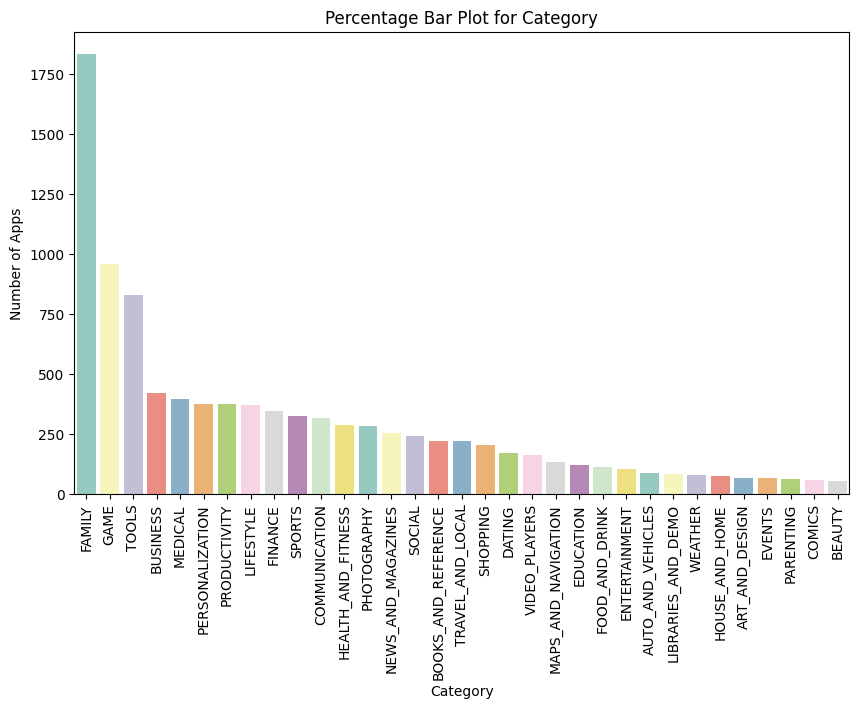

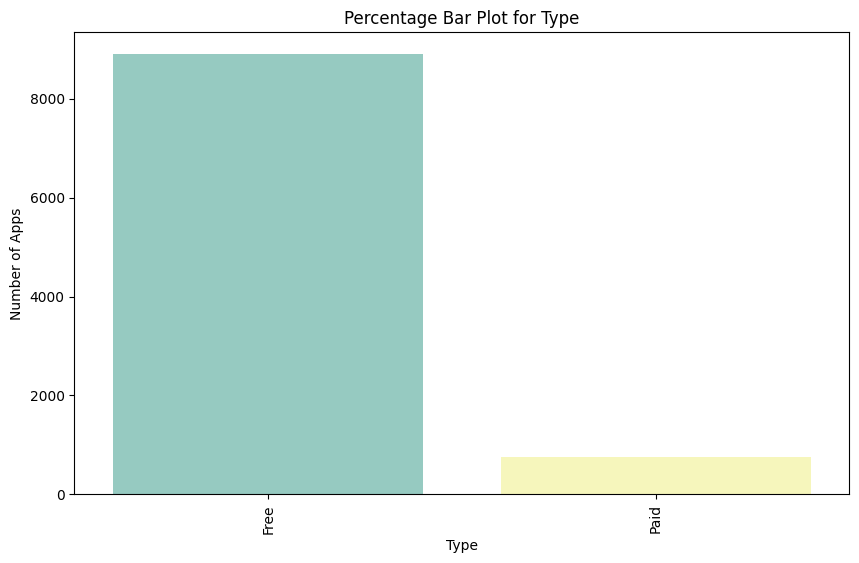

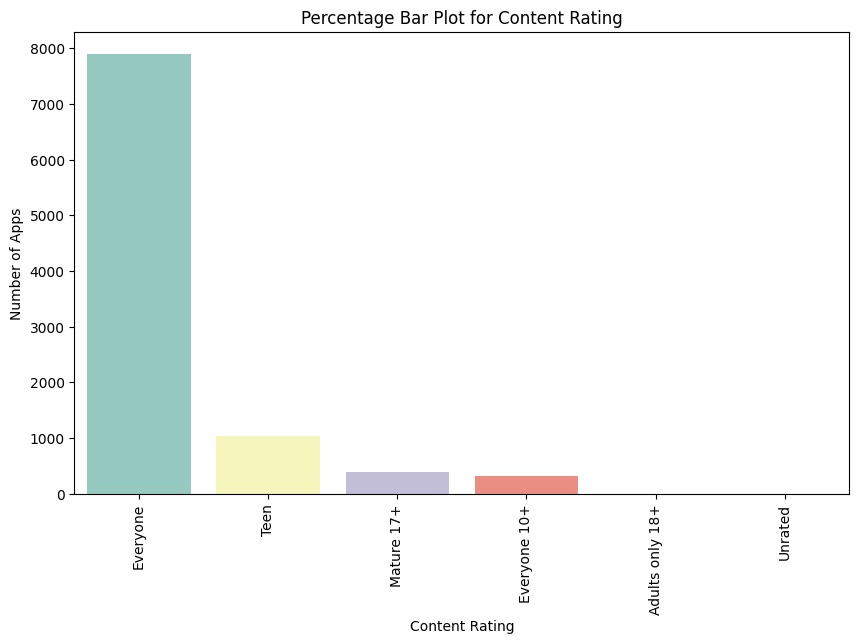

In [ ]:
df_copy['Tpye']=df_copy['Type'].replace('0','Free')

features= ['Category','Type','Content Rating']
print('Univariate Analysis of Categorical Features')
for col in features:
    plt.figure(figsize=(10, 6))
    # Calculate percentage for each category
    counts = df_copy[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette='Set3')
    
    plt.title(f'Percentage Bar Plot for {col}')
    plt.ylabel('Number of Apps')
    plt.xticks(rotation=90)  # Rotate x-ticks if needed
    plt.show()

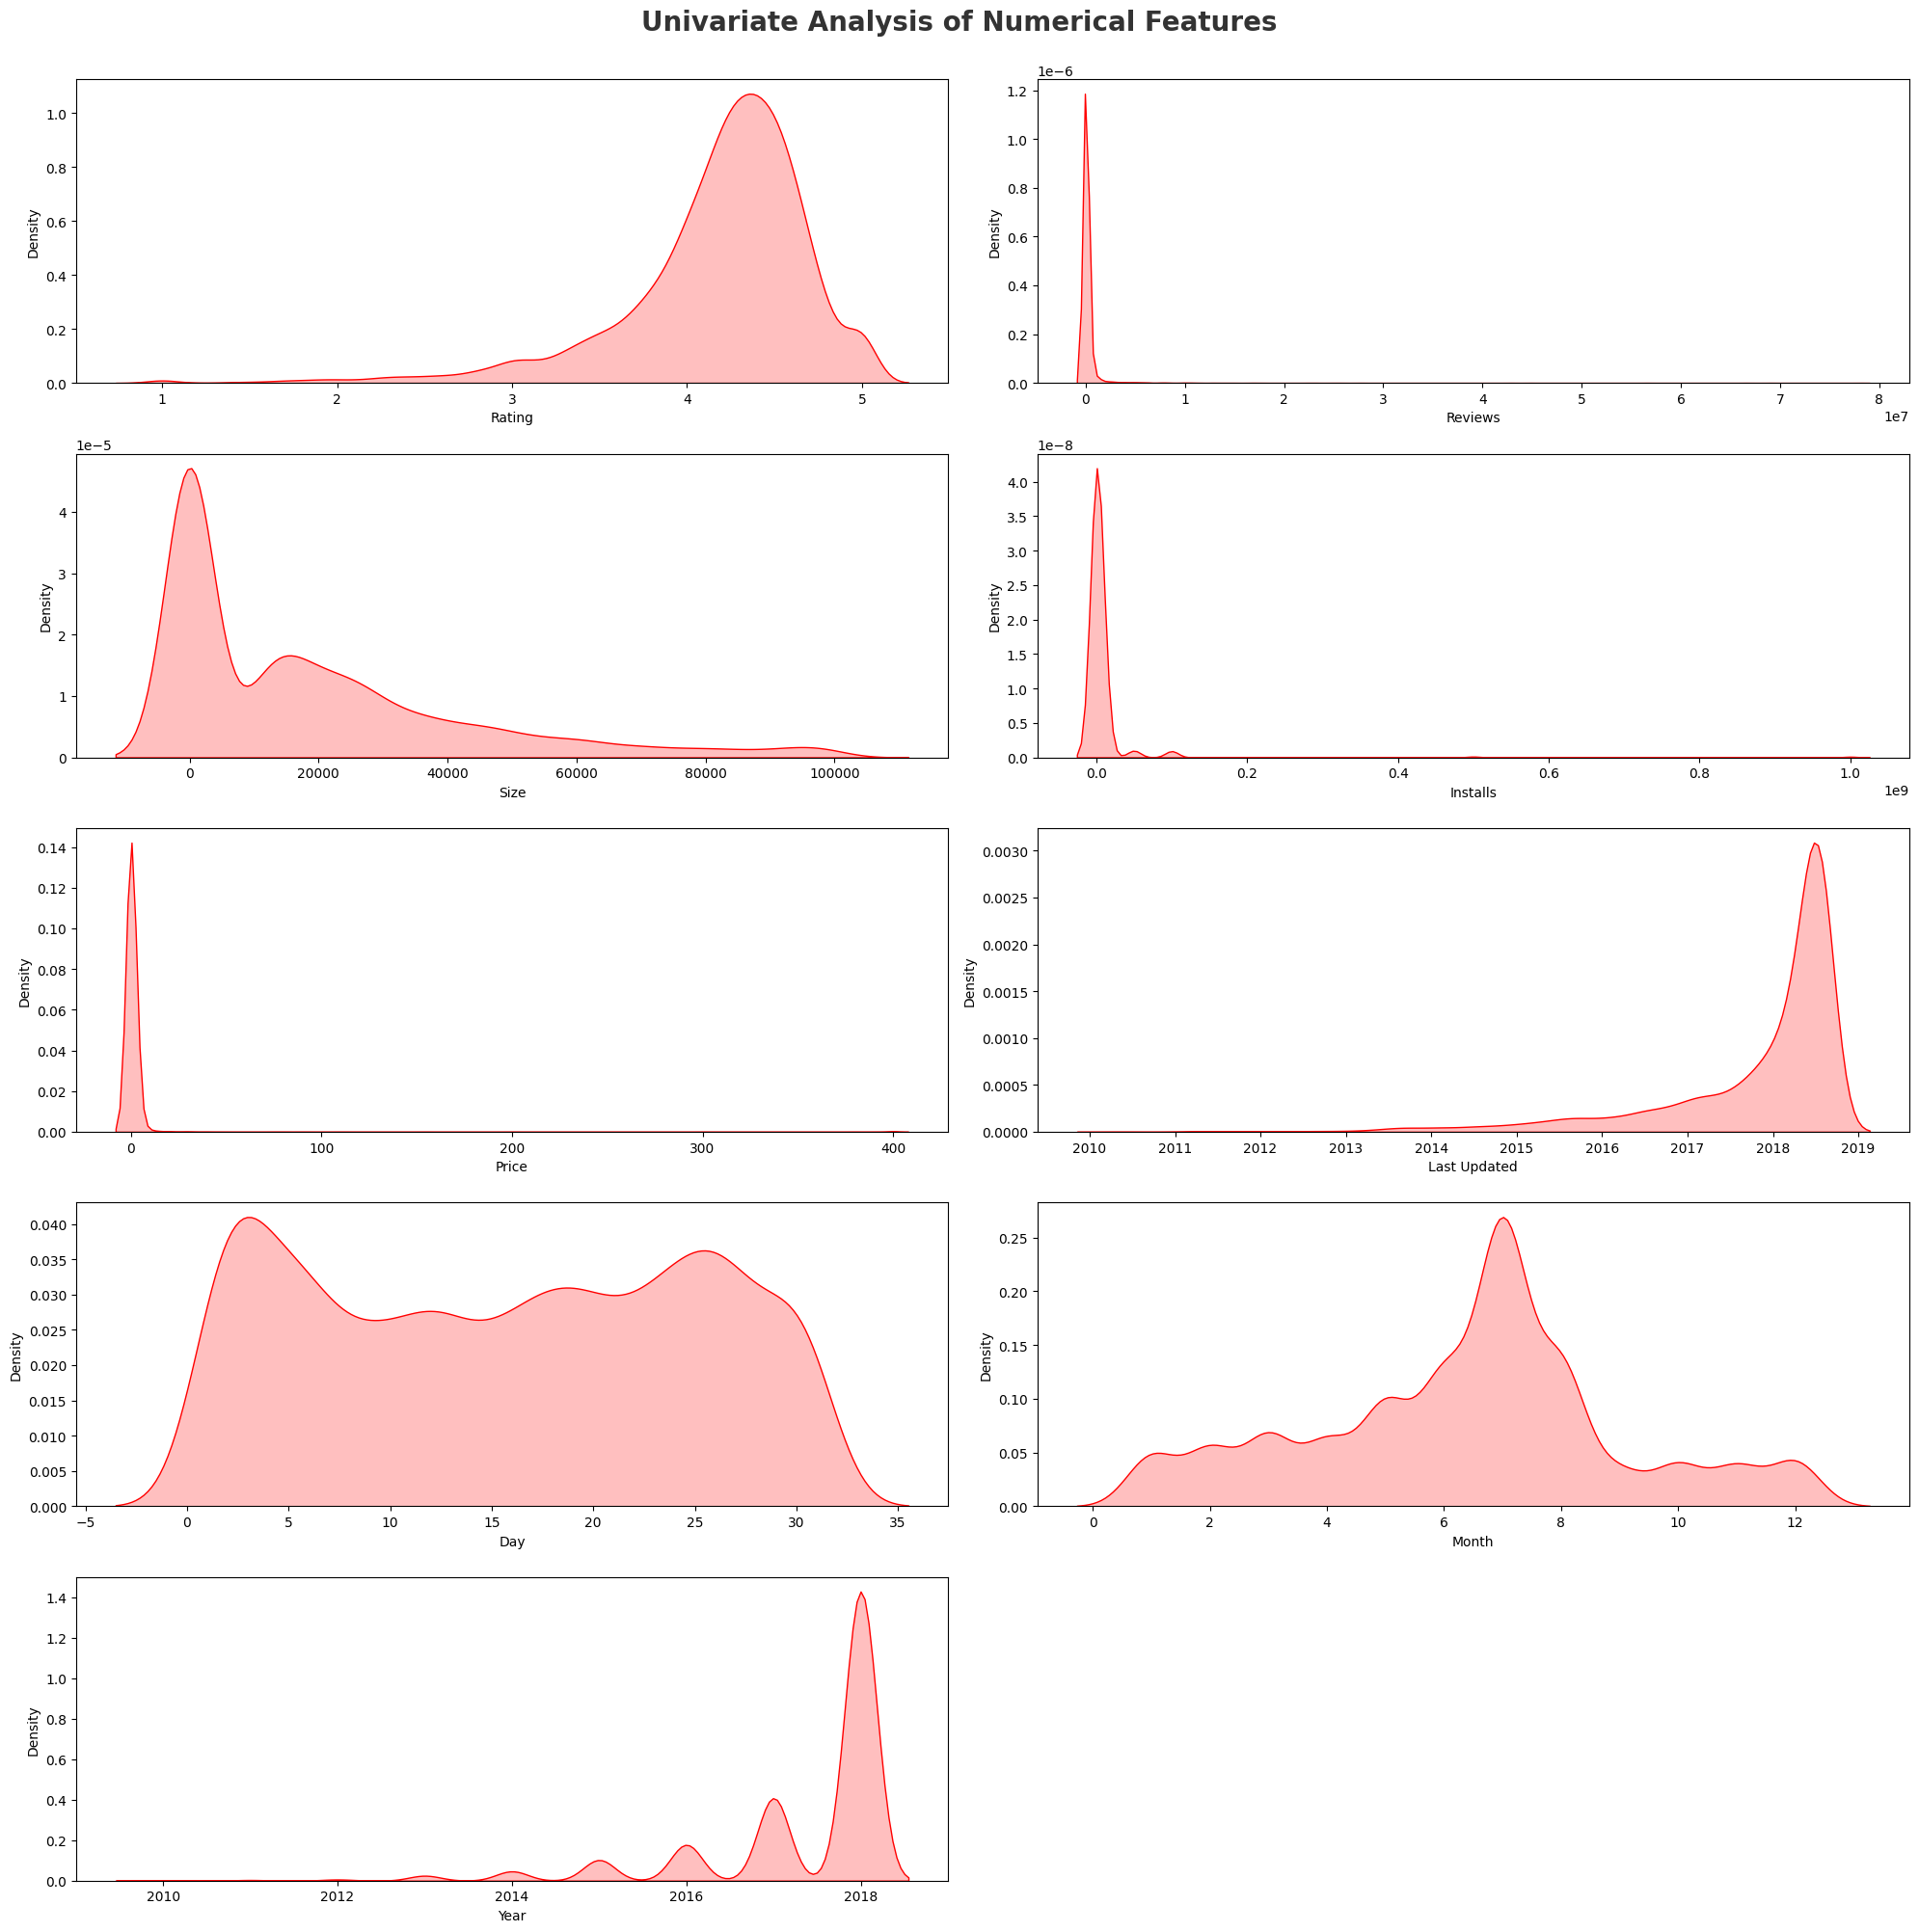

In [ ]:
## Proportion of count data on numerical columns
plt.figure(figsize=(20, 20))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 2, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]],shade=True, color = 'r')#kde plot kernel density estimator
    plt.xlabel(numeric_features[i])
    plt.tight_layout()


Observations

Rating and Year is left skewed while Reviews,Size,Installs and Price are right skewed

In [ ]:
corr=df_copy.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f', cbar=True, 
            linewidths=1, linecolor='black')

ValueError: could not convert string to float: 'Photo Editor & Candy Camera & Grid & ScrapBook'

Text(0.5, 1.0, 'Pie Chart for Category')

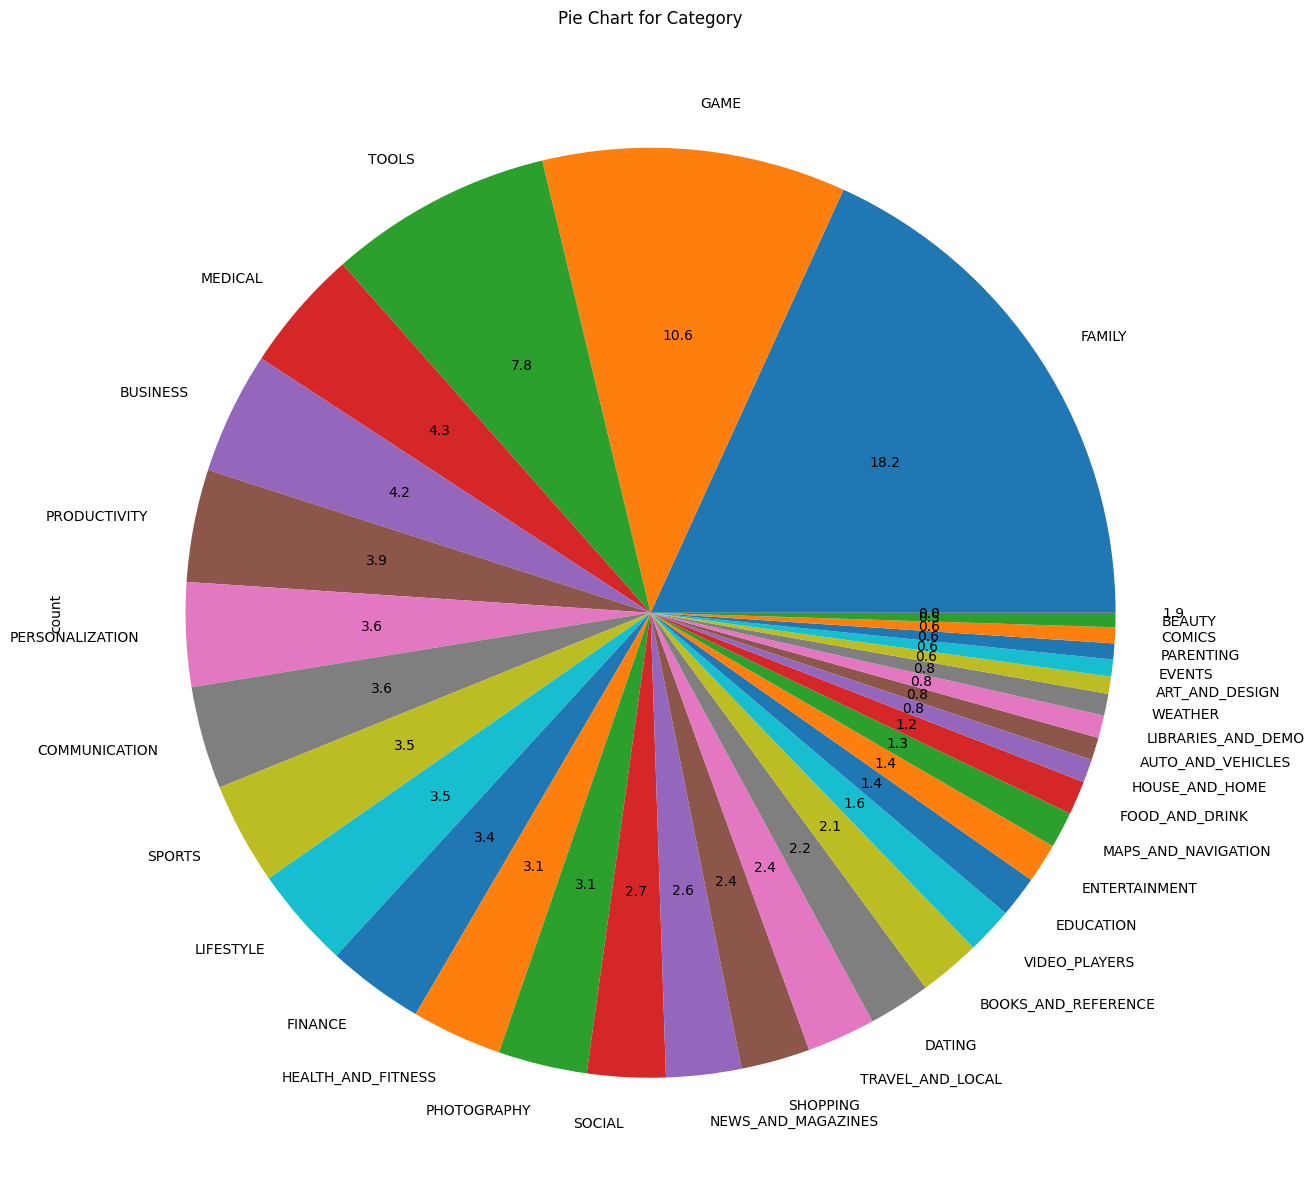

In [ ]:
plt.figure(figsize=(15, 16)) 
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f') 
plt.title(f'Pie Chart for Category')

Observations
There are more kinds of apps in playstore which are under category of family, games & tools
Beatuty,comics,arts and weather kinds of apps are very less in playstore

In [ ]:
category = pd.DataFrame(df_copy['Category'].value_counts())  
category.rename(columns = {'Category':'Count'},inplace=True)
category

category.head()

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395


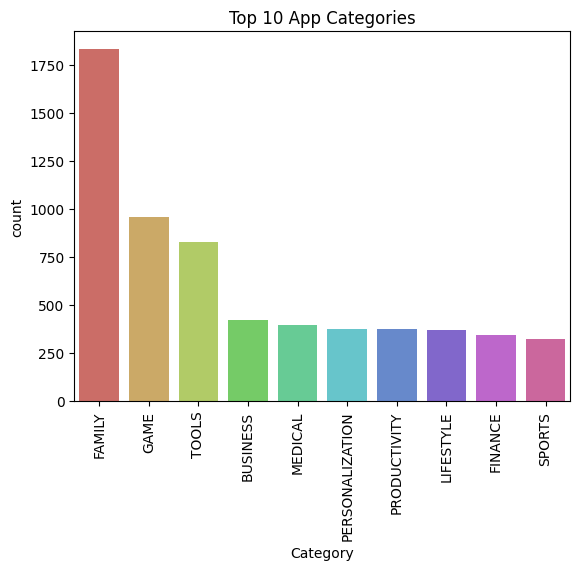

In [ ]:
## top 10 app
sns.barplot(
    x=category.index[:10],
    y=category['count'][:10],
    hue=category.index[:10],   # avoids the palette warning
    palette='hls',
    legend=False
)

plt.title("Top 10 App Categories")
plt.xticks(rotation=90)
plt.show()

Insights
Family category has the most number of apps with 18% of apps belonging to it, followed by Games category which has 11% of the apps.
Least number of apps belong to the Beauty category with less than 1% of the total apps belonging to it.


In [ ]:
# Which Category has largest number of installations??
df_cat_installs = df_copy.groupby(['Category'])['Installs'].sum().sort_values(ascending = False).reset_index()
df_cat_installs.Installs = df_cat_installs.Installs/1000000000# converting into billions
df2 = df_cat_installs.head(10)
df2

,Category,Installs
0,GAME,13.878924
1,COMMUNICATION,11.038276
2,TOOLS,8.001772
3,PRODUCTIVITY,5.793091
4,SOCIAL,5.487868
5,PHOTOGRAPHY,4.649148
6,FAMILY,4.427942
7,VIDEO_PLAYERS,3.926903
8,TRAVEL_AND_LOCAL,2.894887
9,NEWS_AND_MAGAZINES,2.369218


Insights
Out of all the categories "GAME" has the most number of Installations.
With almost 35 Billion Installations GAME is the most popular Category in Google App store

In [ ]:
# What are the Top 5 most installed Apps in Each popular Categories ??
x=df_copy.groupby(['Category','App'])['Installs'].sum().reset_index().sort_values('Installs', ascending = False)
print(x)

                Category                                App    Installs
9342    TRAVEL_AND_LOCAL          Maps - Navigate & Explore  1000000000
1534       ENTERTAINMENT                  Google Play Games  1000000000
9496       VIDEO_PLAYERS            Google Play Movies & TV  1000000000
6388  NEWS_AND_MAGAZINES                        Google News  1000000000
1145       COMMUNICATION      Skype - free IM & video calls  1000000000
...                  ...                                ...         ...
547             BUSINESS                         CX Network           0
3661             FINANCE                        Eu Sou Rico           0
2211              FAMILY          Command & Conquer: Rivals           0
3662             FINANCE                        Eu sou Rico           0
5579           LIFESTYLE  I'm Rich/Eu sou Rico/أنا غني/我很有錢           0

[9659 rows x 3 columns]


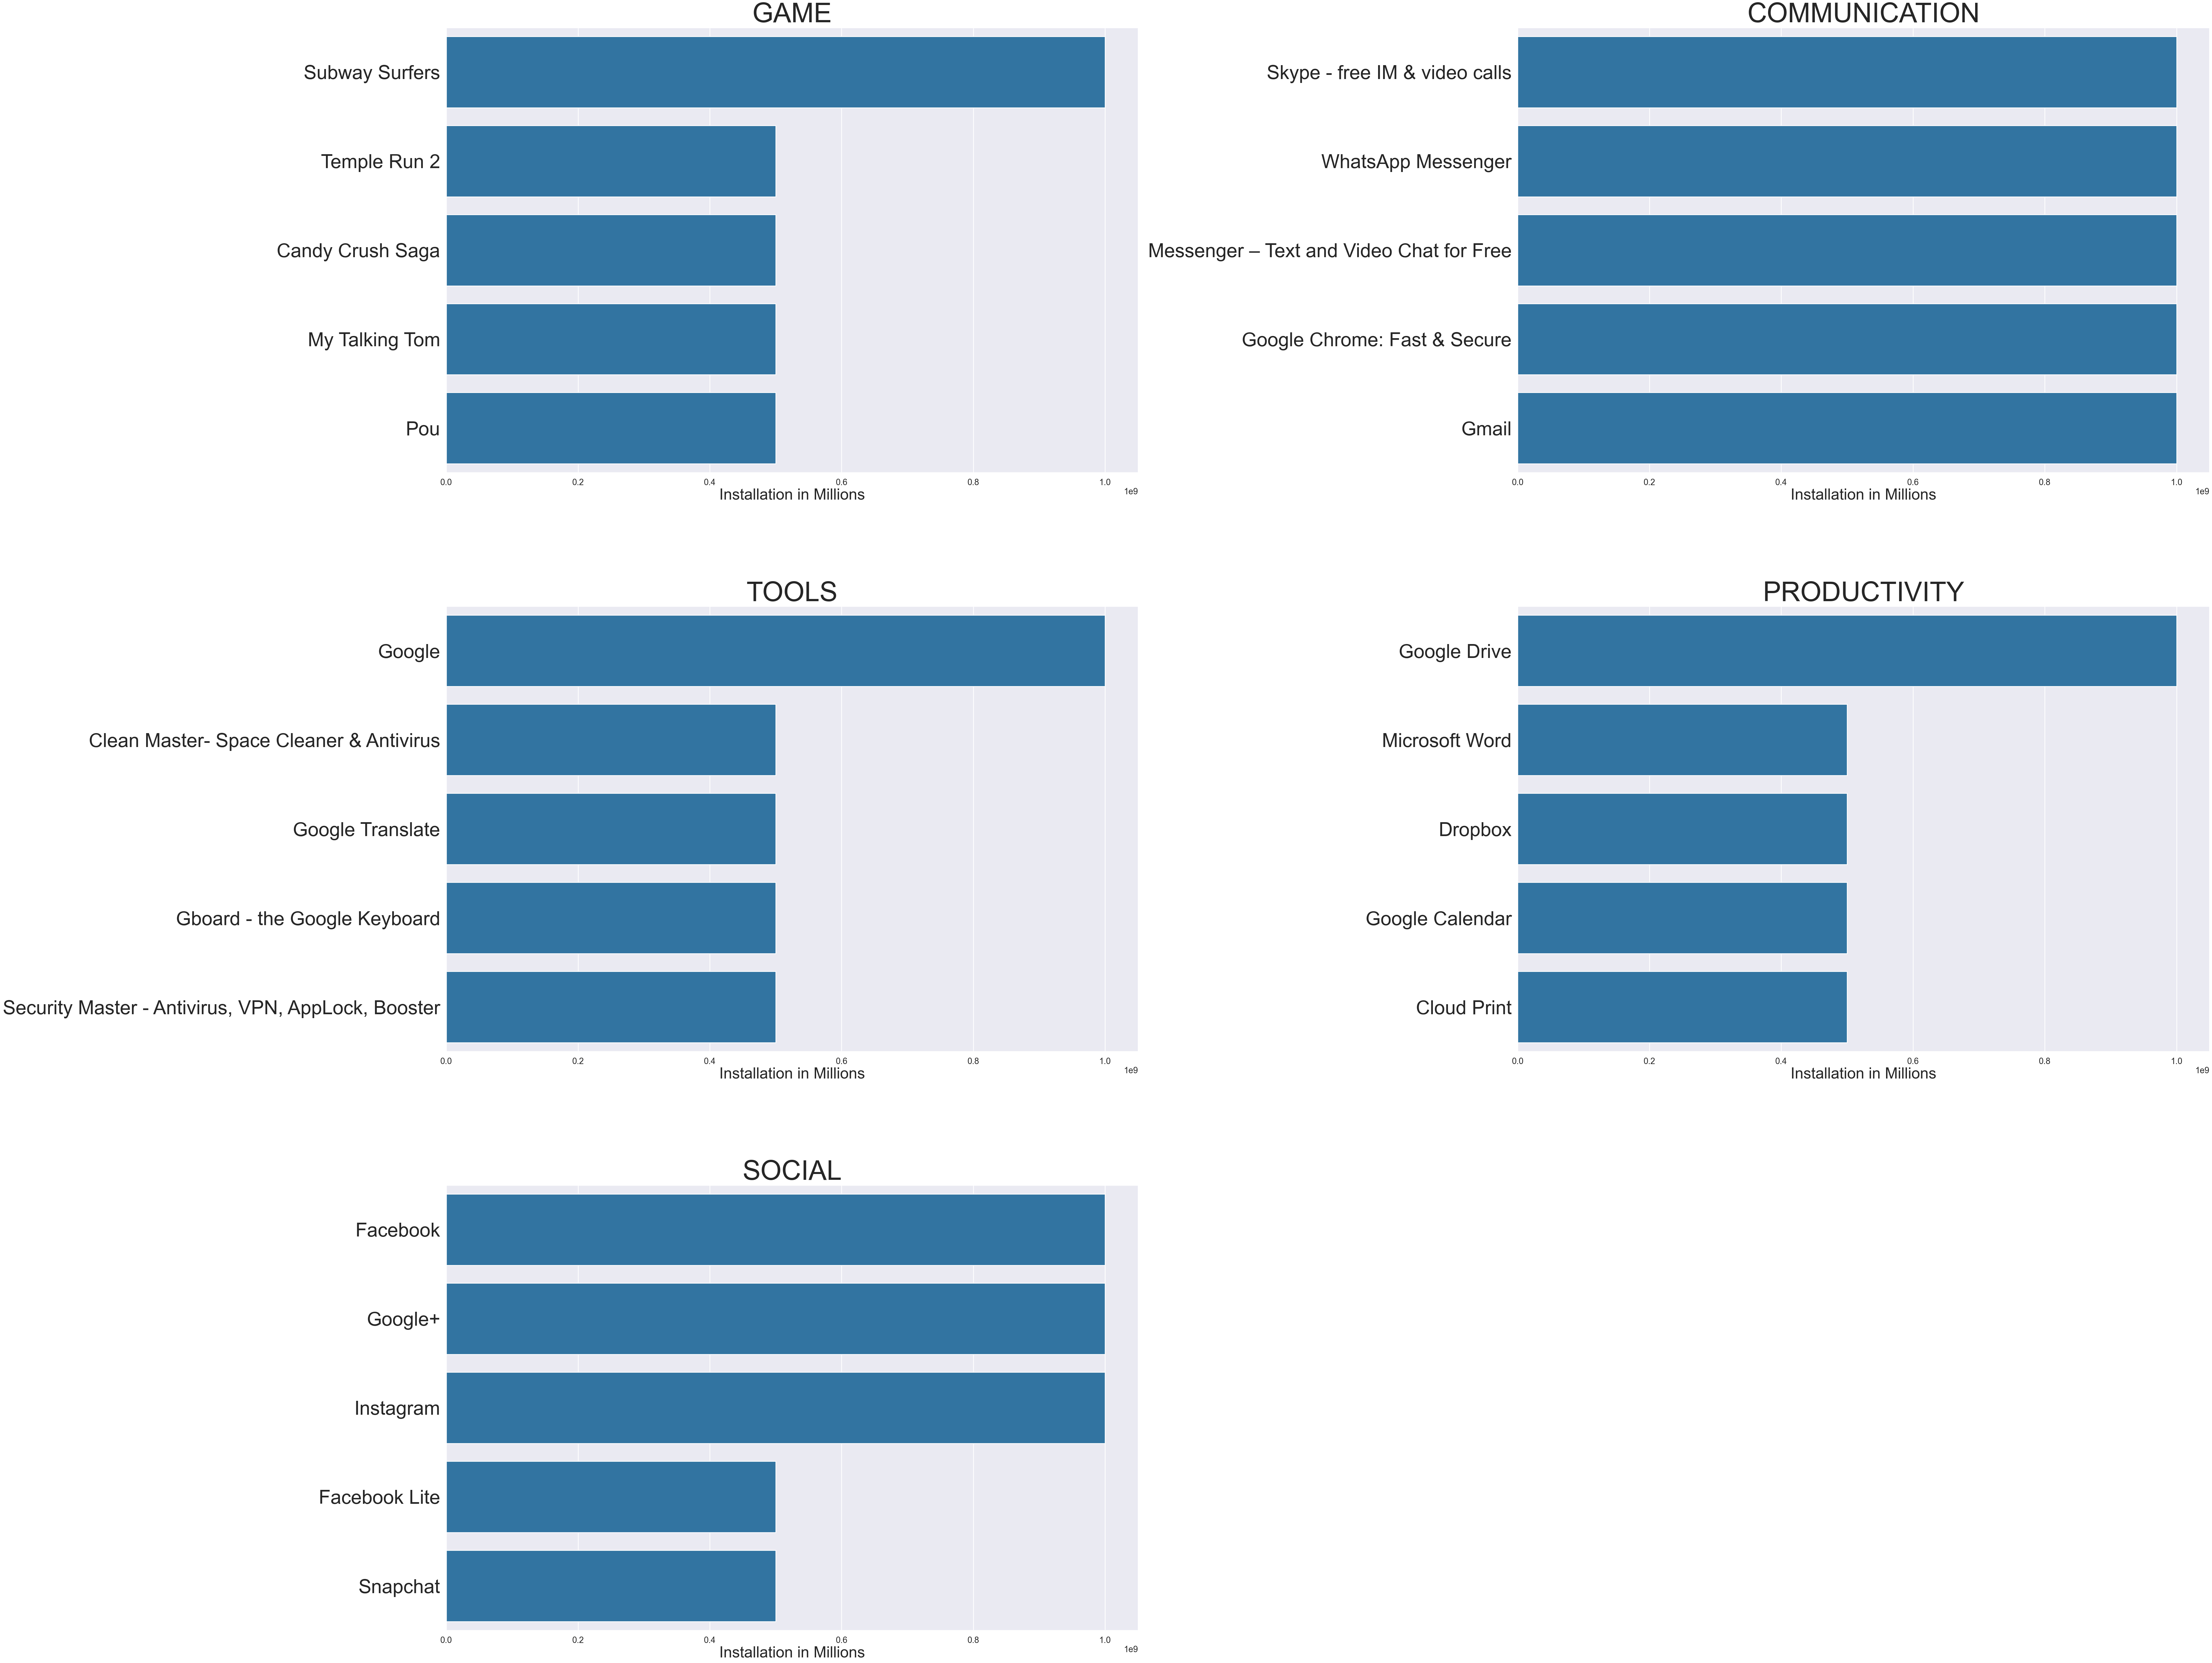

In [ ]:
apps = ['GAME', 'COMMUNICATION','TOOLS', 'PRODUCTIVITY', 'SOCIAL' ]
sns.set_context("poster")
sns.set_style("darkgrid")

plt.figure(figsize=(80,80))
for i,app in enumerate(apps):
    df2 = x[x.Category == app]
    df3 = df2.head(5)
    plt.subplot(4,2,i+1)
    sns.barplot(data= df3,x= 'Installs' ,y='App' )
    plt.xlabel('Installation in Millions',size= 40)
    plt.ylabel('')
    plt.yticks(fontsize=50)
    plt.title(app,size = 70)
    
plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()